# Spectrogram and Filter-Bank Variants

This notebook compares the spectrogram builders and inverse-Mel filter banks exposed by the Python extension.


> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math

import matplotlib.pyplot as plt
import spafe

In [2]:
fs = 16_000
seconds = 1.0
signal = [
    0.6 * math.sin(2.0 * math.pi * 440.0 * n / fs)
    + 0.4 * math.sin(2.0 * math.pi * 1760.0 * n / fs)
    for n in range(int(fs * seconds))
]
opts = spafe.FeatureOptions(fs=fs, nfft=512, nfilts=32, win_hop=0.015)
filter_opts = spafe.FilterBankOptions(nfilts=32, nfft=512, fs=fs, high_freq=8_000.0)

In [3]:
spectrograms = {
    "Mel": spafe.mel_spectrogram(signal, opts).features,
    "Linear": spafe.linear_spectrogram(signal, opts).features,
    "Bark": spafe.bark_spectrogram(signal, opts).features,
    "ERB": spafe.erb_spectrogram(signal, opts).features,
}
{name: (len(matrix), len(matrix[0])) for name, matrix in spectrograms.items()}

{'Mel': (66, 32), 'Linear': (66, 32), 'Bark': (66, 32), 'ERB': (66, 32)}

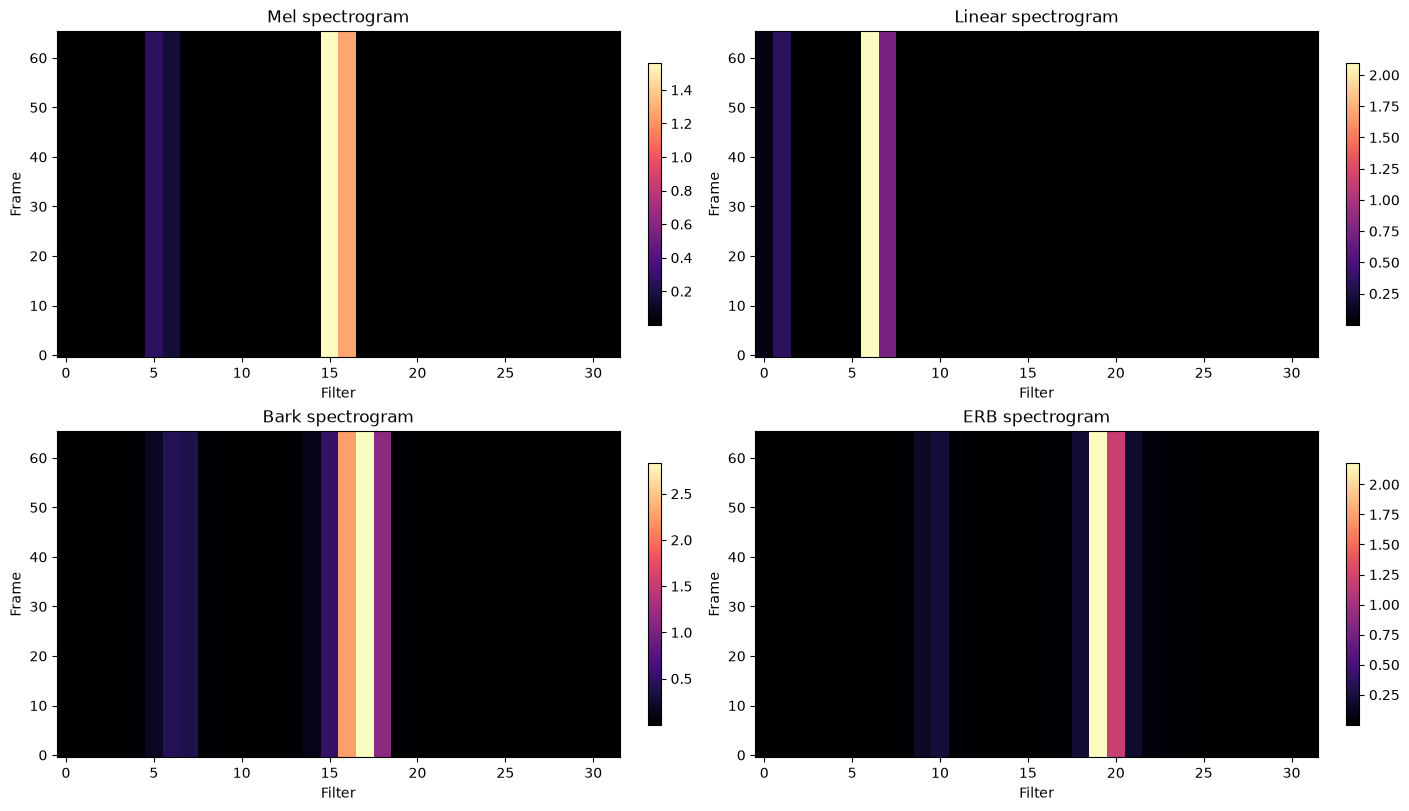

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
for ax, (name, matrix) in zip(axes.ravel(), spectrograms.items()):
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"{name} spectrogram")
    ax.set_xlabel("Filter")
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

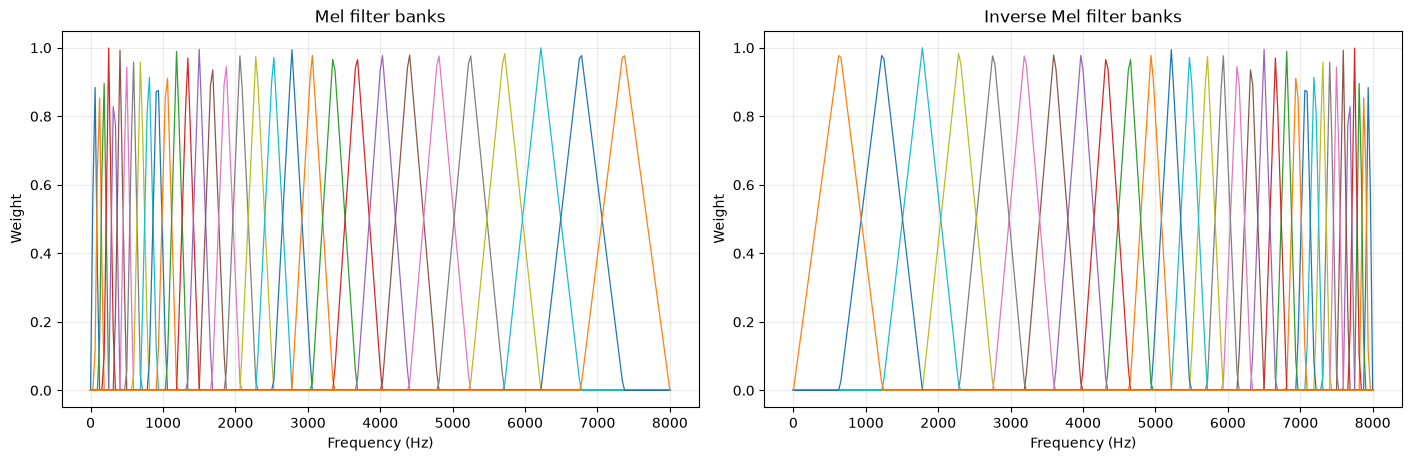

Mel centers: [86.061, 172.123, 258.184, 344.245, 430.307]
Inverse Mel centers: [2832.804, 2824.96, 2816.432, 2807.155, 2797.054]


In [5]:
mel, mel_centers = spafe.mel_filter_banks(filter_opts)
inverse_mel, inverse_centers = spafe.inverse_mel_filter_banks(filter_opts)
freqs = [
    idx * filter_opts.fs / filter_opts.nfft for idx in range(filter_opts.nfft // 2 + 1)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for row in mel:
    axes[0].plot(freqs, row, linewidth=0.9)
for row in inverse_mel:
    axes[1].plot(freqs, row, linewidth=0.9)
axes[0].set_title("Mel filter banks")
axes[1].set_title("Inverse Mel filter banks")
for ax in axes:
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Weight")
    ax.grid(True, alpha=0.25)
plt.show()
print("Mel centers:", [round(value, 3) for value in mel_centers[:5]])
print("Inverse Mel centers:", [round(value, 3) for value in inverse_centers[:5]])